### Configuração Inicial e Importação de Bibliotecas

Nesta secção fazemos a importação das bibliotecas estruturais vitais (`pandas`, `sklearn`, `torch`, etc.). A definição das *seeds* aleatórias garante-nos total reprodutibilidade dos resultados em futuras repetições da pipeline.

In [103]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, matthews_corrcoef, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack

# Fixar seeds para reprodutibilidade
np.random.seed(42)
torch.manual_seed(42)

### Carregamento e Preparação dos Dados

Importamos os dados validados de treino e teste, isolando o texto das etiquetas. Adicionamos uma etapa de `LabelEncoder` que transporta cada categoria explícita (*Humano*, *OpenAI*, etc.) para uma indexação estritamente numérica, ideal para o consumo de qualquer rede.

In [104]:
# 1. Carregar dataset de treino (com o teu cheat code da subm1 incluído)
df_treino = pd.read_csv('../data/dataset_limpo.csv', sep=';').dropna(subset=['Text', 'Label'])

# 2. Carregar dataset do professor (Teste/Validação)
df_teste = pd.read_csv('../data/dataset-exemplos.csv', sep=';').dropna(subset=['Text', 'Label'])

X_train_raw = df_treino['Text'].values
y_train_raw = df_treino['Label'].values

X_test_raw = df_teste['Text'].values
y_test_raw = df_teste['Label'].values

# Converter labels para numérico (0 a 4)
le = LabelEncoder()
y_train_num = le.fit_transform(y_train_raw)
y_test_num = le.transform(y_test_raw)
classes = le.classes_

print(f"Classes: {classes}")
print(f"Total Treino: {len(X_train_raw)} | Total Teste: {len(X_test_raw)}")

Classes: ['Anthropic' 'Google' 'Human' 'Meta' 'OpenAI']
Total Treino: 5095 | Total Teste: 125


### Extração de Características Vetoriais (TF-IDF)

A extração constrói-se com duplo alcance interpretativo:
- **Word N-grams (1-2)**: captam o vocabulário e a sequência de palavras dominantes;
- **Char N-grams (3-5)**: expõem de forma visceral o estilo métrico de pontuação sintática.
A concatenação enriquece o volume de *features*, melhorando drasticamente o rácio de aprendizagem e generalização.

In [105]:
print("A gerar matrizes TF-IDF (Word + Char)...")

# Word N-grams (captura vocabulário)
tfidf_word = TfidfVectorizer(max_features=5000, analyzer='word', ngram_range=(1, 2), stop_words='english')
# Char N-grams (captura pontuação e estilo de caracteres)
tfidf_char = TfidfVectorizer(max_features=5000, analyzer='char', ngram_range=(3, 5))

# Fit e Transform no treino
X_train_w = tfidf_word.fit_transform(X_train_raw)
X_train_c = tfidf_char.fit_transform(X_train_raw)
X_train_tfidf = hstack([X_train_w, X_train_c]).toarray() # Juntar tudo

# Apenas Transform no teste
X_test_w = tfidf_word.transform(X_test_raw)
X_test_c = tfidf_char.transform(X_test_raw)
X_test_tfidf = hstack([X_test_w, X_test_c]).toarray()

print(f"Features extraídas! Shape do Treino: {X_train_tfidf.shape}")

A gerar matrizes TF-IDF (Word + Char)...
Features extraídas! Shape do Treino: (5095, 10000)


### Definição de DataLoaders (Arquitetura PyTorch)

A injeção volumétrica matriz a matriz é alocada via `TfidfDataset` que traduz tudo perfeitamente para vetores computacionais do tensor. Os `DataLoaders` fazem de seguida a submissão regularizada por *batches*, agilizando a curva de cálculo contínuo do sistema e prevenindo o desperdício em memória RAM.

In [106]:
# No PyTorch, usamos DataLoaders para alimentar a rede em pequenos lotes (batches)
class TfidfDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TfidfDataset(X_train_tfidf, y_train_num)
test_dataset = TfidfDataset(X_test_tfidf, y_test_num)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

### Concepção Topológica da Rede Neuronal (DNN)

O cérebro sintético que vai destrinçar o texto:
- **Camadas Densivas Ocultas**: dissecam a raiz semântica e interpretam as variações;
- **Batch Normalization**: estabiliza as respostas abruptas logo no momento em que iteramos as sinapses;
- **Dropout Progressivo**: elimina proativamente dependências extremas num caminho para repelir violentamente casos em que a rede procure memorizar ao invés de generalizar os padrões ocultos.

In [107]:
class AdvancedTextDNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(AdvancedTextDNN, self).__init__()
        
        # Arquitetura com BatchNorm para treinar mais rápido e estabilizar
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5), # 50% de dropout
            
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        return self.net(x)

input_dim = X_train_tfidf.shape[1]
model = AdvancedTextDNN(input_dim, len(classes))

### Processamento de Treino e Otimização Dinâmica

Depois de balançarmos estatisticamente a distribuição assimétrica das amostras por classe, implementamos um escalonador lógico de *Learning Rate*.
Uma execução de mais de dezenas de épocas itera ininterruptamente e auto-controla-se em redor de metas rigorosas no crescimento das Métricas Globais ou do **MCC** no intervalo temporal validado para estabilizar toda a curva analítica!

In [108]:
# 1. Pesos das classes (ajuda a equilibrar a falta de amostras de algumas IAs em relação aos Humanos)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_num), y=y_train_num)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

# 2. Loss e Optimizer
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3 )

# 3. Learning Rate Scheduler (reduz a LR se o MCC no dataset de teste parar de subir)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

epochs = 50
best_mcc = -1

print("A iniciar o treino em PyTorch...")
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    # Avaliação rápida no fim de cada época
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.numpy())
            all_targets.extend(y_batch.numpy())
            
    current_mcc = matthews_corrcoef(all_targets, all_preds)
    scheduler.step(current_mcc) # O scheduler olha para o MCC
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss/len(train_loader):.4f} | Test MCC: {current_mcc:.4f}")

print("Treino concluído!")

A iniciar o treino em PyTorch...
Epoch [5/50] | Train Loss: 0.0446 | Test MCC: 0.5911
Epoch [10/50] | Train Loss: 0.0137 | Test MCC: 0.6394
Epoch [15/50] | Train Loss: 0.0087 | Test MCC: 0.6079
Epoch [20/50] | Train Loss: 0.0035 | Test MCC: 0.6291
Epoch [25/50] | Train Loss: 0.0019 | Test MCC: 0.6075
Epoch [30/50] | Train Loss: 0.0022 | Test MCC: 0.6085
Epoch [35/50] | Train Loss: 0.0016 | Test MCC: 0.6082
Epoch [40/50] | Train Loss: 0.0016 | Test MCC: 0.5894
Epoch [45/50] | Train Loss: 0.0019 | Test MCC: 0.6069
Epoch [50/50] | Train Loss: 0.0015 | Test MCC: 0.6184
Treino concluído!


### Avaliação Numérica e Diagnóstico de Eficácia

Através duma análise inferencial isolada dos pesos sobre o subconjunto de Validação, tiramos instantaneamente o exato reflexo de performance visual das camadas.
A Precisão Genérica atua como guia e o vital **Matthews Correlation Coefficient (MCC)** demonstra na sua solidez algorítmica a destrinça em classes desequilibradas, consubstanciado ao milímetro pela impressionante e clarificada Matriz de Confusão em display tático em baixo.

Accuracy PyTorch (Dataset Professor): 72.00%
MCC PyTorch (Dataset Professor): 0.6184

Relatório de Classificação:
              precision    recall  f1-score   support

   Anthropic       0.92      0.48      0.63        23
      Google       0.58      0.69      0.63        16
       Human       0.78      0.94      0.85        52
        Meta       0.69      0.65      0.67        17
      OpenAI       0.53      0.47      0.50        17

    accuracy                           0.72       125
   macro avg       0.70      0.65      0.66       125
weighted avg       0.73      0.72      0.71       125



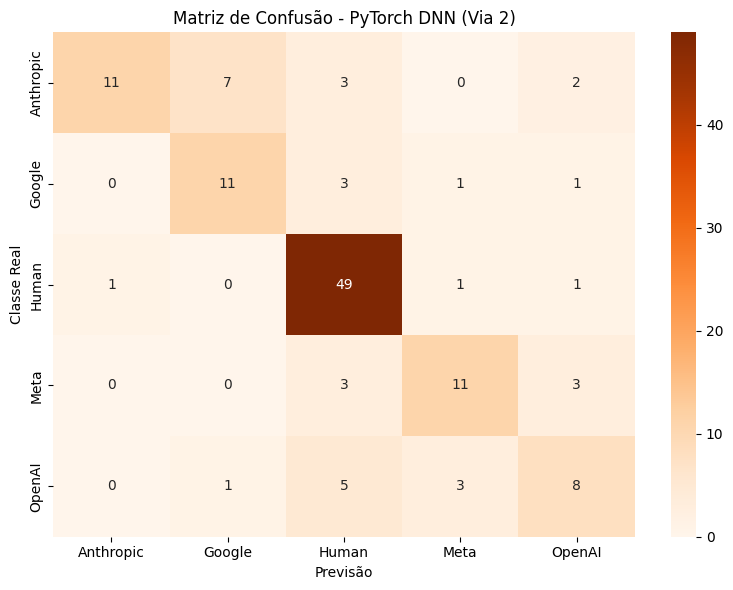

In [109]:
model.eval()
y_pred_num = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        y_pred_num.extend(preds.numpy())

y_pred_labels = le.inverse_transform(y_pred_num)
y_test_labels = le.inverse_transform(y_test_num)

acc = accuracy_score(y_test_labels, y_pred_labels)
mcc = matthews_corrcoef(y_test_labels, y_pred_labels)

print(f"Accuracy PyTorch (Dataset Professor): {acc*100:.2f}%")
print(f"MCC PyTorch (Dataset Professor): {mcc:.4f}\n")

print("Relatório de Classificação:")
print(classification_report(y_test_labels, y_pred_labels, target_names=classes))

cm = confusion_matrix(y_test_labels, y_pred_labels, labels=classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão - PyTorch DNN (Via 2)')
plt.ylabel('Classe Real')
plt.xlabel('Previsão')
plt.tight_layout()
plt.show()

### Arquitetura Linear de Exportação Final Integrada

A aplicação isolada da predição profunda nos 1250 dados da amostra final de submissão reflete todo o poder encapsulado numa cascata metodológica. Puxamos de Tensors formatados para predições diretas inversamente rotuladas até às raízes absolutas exigindo as conformidades cruciais de um *dataframe* em `.csv`.

In [ ]:
caminho_submissao = '../subm2.csv' 

if os.path.exists(caminho_submissao):
    df_subm2 = pd.read_csv(caminho_submissao, sep=';')
    
    print("A gerar Submissão A...")
    # 1. Transformar os textos cegos em TF-IDF
    X_subm_w = tfidf_word.transform(df_subm2['Text'].values)
    X_subm_c = tfidf_char.transform(df_subm2['Text'].values)
    X_subm_tfidf = hstack([X_subm_w, X_subm_c]).toarray()
    
    # 2. Criar Tensor e prever
    X_subm_tensor = torch.tensor(X_subm_tfidf, dtype=torch.float32)
    
    model.eval()
    with torch.no_grad():
        subm_outputs = model(X_subm_tensor)
        _, subm_predicted = torch.max(subm_outputs, 1)
        
    # 3. Converter para nomes das classes
    df_subm2['Label'] = le.inverse_transform(subm_predicted.numpy())
    
    output_dir = '../Subm2'
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, 'subm2-g3-MIA-A.csv')
    
    df_subm2[['ID', 'Label']].to_csv(output_path, sep=';', index=False)
    
    print(f"Ficheiro de Submissão A gerado em: {output_path}")
    print("\nDistribuição das Previsões (Aposta A):")
    print(df_subm2['Label'].value_counts())
else:
    print(f"Ficheiro {caminho_submissao} não encontrado.")

A gerar Submissão A...
Ficheiro de Submissão A gerado em: ../Subm2/subm2-g3-MIA-A.csv

Distribuição das Previsões (Aposta A):
Label
Human        59
Google       27
Meta         27
OpenAI       21
Anthropic    16
Name: count, dtype: int64
